In [ ]:
from pathlib import Path
from rosbags.highlevel import AnyReader
from rosbags.typesys import Stores, get_typestore
from pyproj import Transformer
from scipy.spatial.transform import Rotation as R
import pandas as pd

import numpy as np
from scipy.spatial.transform import Rotation as R

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime

#---------- PARAMS -----------
KT = 0.199  # motors torque constant
POLE_PAIR = 21
GR = 8

# ---------------- setup ----------------
typestore = get_typestore(Stores.ROS2_JAZZY)
transformer = Transformer.from_crs("epsg:4978", "epsg:4326", always_xy=True)

required_topics = {
    '/fixposition/fpa/odomenu'
    '/vehicle_throttle',
    '/steering_pub',
    '/steering_feedback',
    '/vehicle_feedback'
}

bagpath = Path("../bags/day1_thottle_test_v0/")
    

# ---------------- read bag ----------------
with AnyReader([bagpath], default_typestore=typestore) as reader:
    connections = [c for c in reader.connections if c.topic in required_topics]

    for c, t, raw in reader.messages(connections=connections):

        msg = reader.deserialize(raw, c.msgtype)
        time = t * 1e-9  # ns → seconds
        time = datetime.fromtimestamp(time)

        row = {"time": time}

        # -------- odometry --------
        
        p = msg.pose.pose.position
        q = msg.pose.pose.orientation
        v = msg.velocity.twist.linear
        w = msg.velocity.twist.angular
        a = msg.acceleration 

        lon, lat, alt = transformer.transform(p.x, p.y, p.z)
        yaw, pitch, roll = R.from_quat(
            [q.x, q.y, q.z, q.w]
        ).as_euler("zyx", degrees=True)
        

        row.update({
            "lat": lat,
            "lon": lon,
            "alt": alt,
            "yaw": yaw,
            "pitch": pitch,
            "roll": roll,
            "vx":v.x,
            "vy":v.y,
            "vz":v.z,
            "ax": a.x, 
            "ay": a.y, 
            "az": a.z,
            "yaw_rate": w.x, 
            "pitch_rate": w.y,
            "roll_rate": w.z
        })
        
        # -------- motor feedback --------
        # if c.topic == '/motor_feedback':
        #     row.update({
        #         "pos": msg.data[0],
        #         "rpm": msg.data[1]*(POLE_PAIR*GR),
        #         "torque": msg.data[2]*KT,
        #         "temp": msg.data[3],
        #         "err": msg.data[4]
        #     })

        # # -------- steering --------
        # if c.topic == '/steering_pub':
        #     row.update({
        #         "steering_vel": msg.linear.x
        #     })


# ---------------- dataframe ----------------

df = pd.DataFrame(rows)  #.sort_values("time")

df.yaw = df.yaw*np.pi/180
df['uncorrect_yaw'] = df.yaw
df.yaw = np.unwrap(df.yaw)

csv_path = f"./brake_csv/{bagpath.name.replace(".bag", "_data.csv")}"
df.to_csv(csv_path, index=True)

In [4]:
from pathlib import Path
from rosbags.highlevel import AnyReader
from rosbags.typesys import Stores, get_typestore
import pandas as pd
from datetime import datetime

# ---------------- CONFIG ----------------
# Path to your recovered ROS 2 bag (folder or mcap file)
# bagpath = Path("../bags/day1_thottle_test_v0/")
bagpath = Path("../bags/day1_thottle_test_v0/rec_v16/rec_v16.mcap") 

# Topics to extract
topics_of_interest = {
    '/fixposition/fpa/odomenu',
    '/vehicle_feedback',
    '/steering_feedback',
    '/steering_pub',
    '/vehicle_throttle'
}

# ---------------- SETUP ----------------
# ROS 2 Jazzy typestore (includes standard msgs like Twist, Float32MultiArray)
typestore = get_typestore(Stores.ROS2_JAZZY)

rows = []

# ---------------- READ BAG ----------------
with AnyReader([bagpath], default_typestore=typestore) as reader:
    
    # Filter for connections to only the topics we want
    connections = [c for c in reader.connections if c.topic in topics_of_interest]
    
    for connection, timestamp, rawdata in reader.messages(connections=connections):
        
        # Deserialize based on message type
        msg = reader.deserialize(rawdata, connection.msgtype)
        
        # Convert ROS 2 timestamp (nanoseconds) to datetime
        t_sec = timestamp * 1e-9
        dt_object = datetime.fromtimestamp(t_sec)
        
        # Base row with common time info
        row = {
            "time_ns": timestamp,
            "datetime": dt_object,
            "topic": connection.topic
        }

        # --- CASE 1: Vehicle Feedback (Float32MultiArray) ---
        # Structure from your C++: [Throttle, Brake, RPM, Current]
        if connection.topic == '/vehicle_feedback':
            row.update({
                "veh_throttle_fb": msg.data[0],
                "veh_brake_fb":    msg.data[1],
                "veh_rpm_fb":      msg.data[2],
                "veh_current_fb":  msg.data[3]
            })

        # --- CASE 2: Steering Feedback (Float32MultiArray) ---
        # Structure from your C++: [Pos, Spd, Cur, Temp, Err]
        elif connection.topic == '/steering_feedback':
            row.update({
                "str_pos_fb":  msg.data[0],
                "str_spd_fb":  msg.data[1],
                "str_cur_fb":  msg.data[2],
                "str_temp_fb": msg.data[3],
                "str_err_fb":  msg.data[4]
            })

        # --- CASE 3: Steering Command (Twist) ---
        elif connection.topic == '/steering_pub':
            row.update({
                "str_cmd_val": msg.linear.x,  # The command you sent
                "str_cmd_takeover": msg.linear.y # -1 if takeover
            })

        # --- CASE 4: Vehicle Throttle Command (Twist) ---
        elif connection.topic == '/vehicle_throttle':
            row.update({
                "veh_cmd_throttle": msg.linear.x,
                "veh_cmd_brake":    msg.linear.y
            })
        elif connection.topic == '/fixposition/fpa/odomenu':
            # p = msg.pose.pose.position
            # q = msg.pose.pose.orientation
            v = msg.velocity.twist.linear
            # w = msg.velocity.twist.angular
            a = msg.acceleration 

            # lon, lat, alt = transformer.transform(p.x, p.y, p.z)
            # yaw, pitch, roll = R.from_quat(
            #     [q.x, q.y, q.z, q.w]
            # ).as_euler("zyx", degrees=True)
            

            row.update({
                "vx":v.x,
                "vy":v.y,
                "vz":v.z,
                "ax": a.x, 
                "ay": a.y, 
                "az": a.z
                # "yaw_rate": w.x, 
                # "pitch_rate": w.y,
                # "roll_rate": w.z
            })

        rows.append(row)

# ---------------- PROCESS DATA ----------------
df = pd.DataFrame(rows)

## Checking the data frequency and consistency 

In [8]:
df.columns

Index(['time_ns', 'datetime', 'topic', 'vx', 'vy', 'vz', 'ax', 'ay', 'az',
       'str_pos_fb', 'str_spd_fb', 'str_cur_fb', 'str_temp_fb', 'str_err_fb',
       'str_cmd_val', 'str_cmd_takeover', 'veh_throttle_fb', 'veh_brake_fb',
       'veh_rpm_fb', 'veh_current_fb', 'veh_cmd_throttle', 'veh_cmd_brake'],
      dtype='object')

In [5]:
df.describe()

,time_ns,datetime,vx,vy,vz,ax,ay,az,str_pos_fb,str_spd_fb,...,str_temp_fb,str_err_fb,str_cmd_val,str_cmd_takeover,veh_throttle_fb,veh_brake_fb,veh_rpm_fb,veh_current_fb,veh_cmd_throttle,veh_cmd_brake
count,2.847500e+04,28475,5472.000000,5472.000000,5472.000000,5472.000000,5472.000000,5472.000000,6313.0,6313.0,...,6313.0,6313.0,5196.000000,5196.000000,6304.000000,6304.000000,6304.000000,6304.000000,5190.000000,5190.000000
mean,1.769434e+18,2026-01-26 18:52:19.478002944,-0.015115,-0.002432,-0.003736,-0.034270,-0.019585,9.809235,0.0,0.0,...,0.0,0.0,-26.610758,-0.000192,-650.363737,3891.953997,-0.332011,521.425920,-897.467245,-15.635260
min,1.769434e+18,2026-01-26 18:50:02.055795,-3.555100,-0.313200,-0.205000,-13.365000,-3.767200,7.973700,0.0,0.0,...,0.0,0.0,-6000.000000,-1.000000,-32767.000000,0.000000,-1152.000000,16.000000,-32767.000000,-32767.000000
25%,1.769434e+18,2026-01-26 18:51:08.471701504,-0.422900,-0.025500,-0.005600,-0.180950,-0.146200,9.776400,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,-125.000000,37.000000,-5782.000000,0.000000
50%,1.769434e+18,2026-01-26 18:52:17.948705024,-0.001200,-0.000700,-0.000100,-0.023700,-0.023500,9.808600,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.000000,2195.000000,0.000000,441.000000,0.000000,0.000000
75%,1.769434e+18,2026-01-26 18:53:32.076351488,0.228225,0.016800,0.003000,0.085325,0.065225,9.842200,0.0,0.0,...,0.0,0.0,0.000000,0.000000,1523.000000,7340.000000,80.000000,813.000000,2954.000000,0.000000
max,1.769434e+18,2026-01-26 18:54:38.795706,5.474500,0.259500,0.061400,4.279400,4.206600,11.362400,0.0,0.0,...,0.0,0.0,6000.000000,0.000000,32767.000000,32767.000000,1639.000000,2448.000000,32766.000000,32767.000000
std,8.081908e+10,NaN,1.080069,0.064603,0.020780,0.514388,0.323115,0.168814,0.0,0.0,...,0.0,0.0,1519.440288,0.013873,10866.416682,4219.538754,317.298148,515.336105,11273.059495,2750.096689


In [ ]:
# count the nans -  ? 
# note the delta t's - then plot it - like histogram -- for each variable 
# diff between timestamps - after dropping the nan values - separetly for each axis b

datetime        0
vx          23003
dtype: int64
 mean is 50.58305812465728 and median 47.015 and std 28.10374734271249


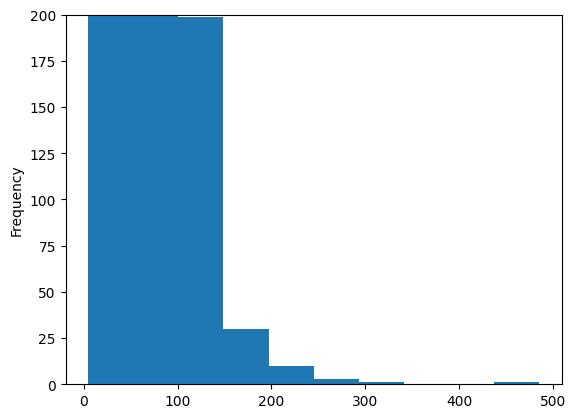

In [ ]:
ifb = df[['datetime', 'vx']]
# print(ifb.isna().sum())
ifb_n = ifb.dropna(subset=['vx'])

# print(ifb.isna().sum())
time = ifb_n.datetime.diff().dt.total_seconds()*1000  #  its in milliseconds a
# time = 
time.plot(kind='hist' , ylim=(0,200))

print(f" mean is {time.mean()} and median {time.median()} and std {time.std()}")

#mean is 50.58305812465728 and median 47.015 and std 28.10374734271249

 mean is 43.779853295310524 and median 31.442499999999995 and std 37.33979866487937


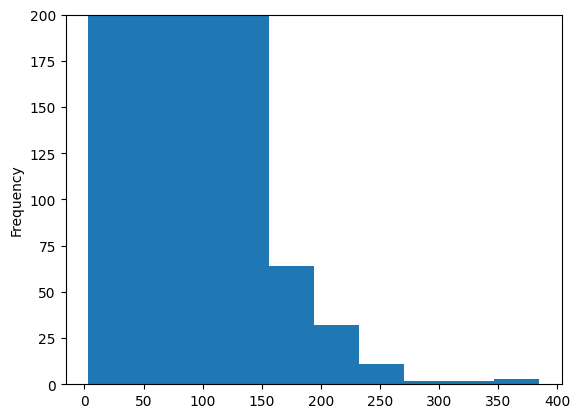

In [34]:
sfb = df[['datetime', 'str_pos_fb']]
sfb_n = sfb.dropna(subset=['str_pos_fb'])
time = sfb_n.datetime.diff().dt.total_seconds()*1000  #  its in milliseconds a
# time = 
time.plot(kind='hist' , ylim=(0,200))

print(f" mean is {time.mean()} and median {time.median()} and std {time.std()}")

# mean is 43.779853295310524 and median 31.442499999999995 and std 37.33979866487937        -- the median is very low -- and how is loop running at lower than 50ms? 

 mean is 43.794492463906074 and median 31.387999999999998 and std 37.3676158810496


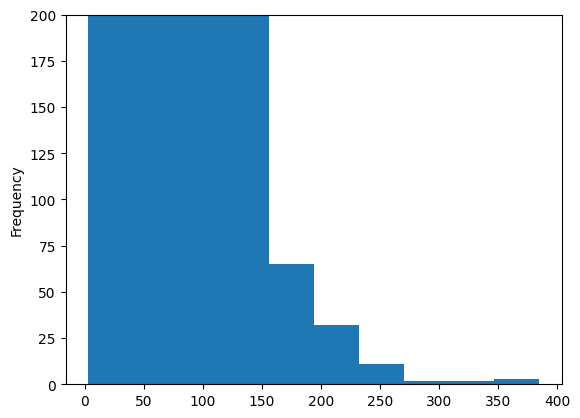

In [33]:
vfb = df[['datetime', 'veh_throttle_fb']]
vfb_n = vfb.dropna(subset=['veh_throttle_fb'])
time = vfb_n.datetime.diff().dt.total_seconds()*1000  #  its in milliseconds a

time.plot(kind='hist' , ylim=(0,200))

print(f" mean is {time.mean()} and median {time.median()} and std {time.std()}")
#mean is 43.794492463906074 and median 31.387999999999998 and std 37.3676158810496

## Plot the throttle command and the accel from the data

In [ ]:
# v.describe()

,vx,ax,veh_throttle_fb
count,0.0,0.0,0.0
mean,NaN,NaN,NaN
std,NaN,NaN,NaN
min,NaN,NaN,NaN
25%,NaN,NaN,NaN
50%,NaN,NaN,NaN
75%,NaN,NaN,NaN
max,NaN,NaN,NaN


/tmp/ipykernel_31543/546386871.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  v.veh_throttle_fb = v.veh_throttle_fb/32767


<Axes: >

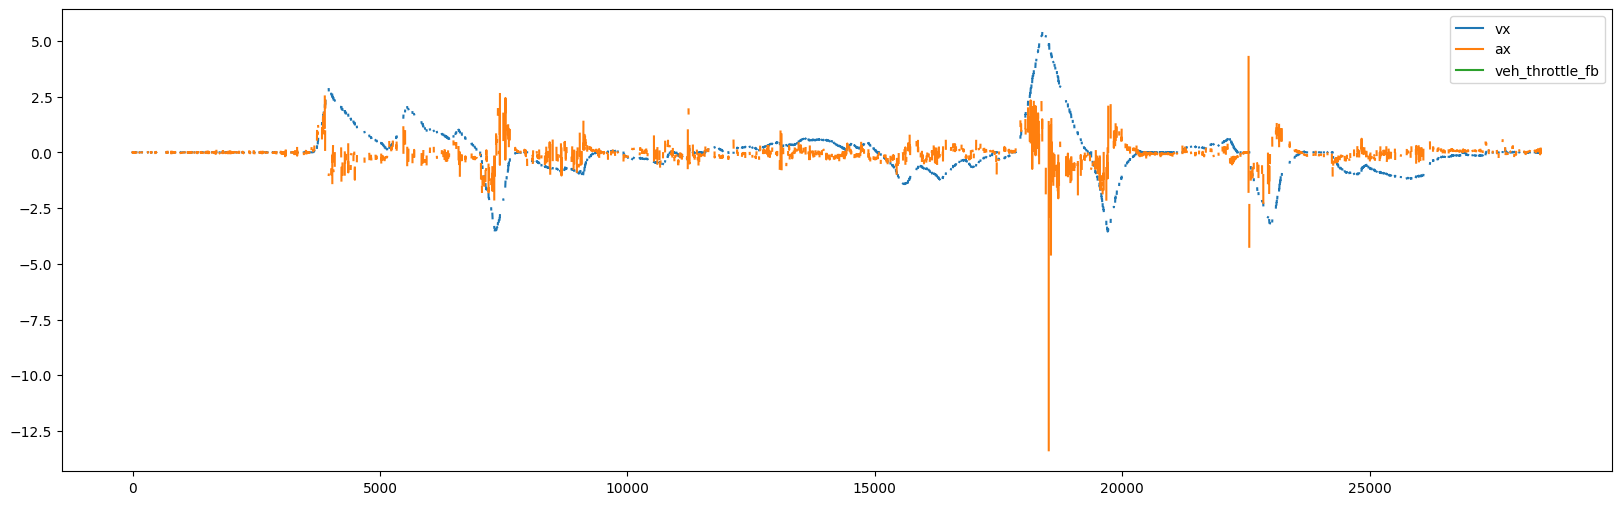

In [41]:
# pdf = df.dropna(subset=['vx','ax','veh_throttle_fb'])
v = df[['vx' , 'ax' , 'veh_throttle_fb']]
v.veh_throttle_fb = v.veh_throttle_fb/32767

v.plot(figsize=(20,6))

In [ ]:
# The dataframe is currently "long" (sparse), let's make it more usable
# by backfilling values so each row has the state of the system at that time
df = df.sort_values('time_ns')
df = df.ffill().dropna(subset=['datetime']) # Forward fill previous values to align timestamps

# Export
csv_name = bagpath.name.replace('.mcap', '.csv')
df.to_csv(csv_name, index=False)
print(f"Saved {len(df)} messages to {csv_name}")
print(df.head())